<a href="https://colab.research.google.com/github/victoria-analyst/Exploratory-Data-Analysis-for-an-International-E-commerce-Company/blob/main/Project_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Блок 1. Попередня робота з даними

###Завантаження даних. Імпортування бібліотек

In [ ]:
#Connecting to database
!pip install --upgrade google-cloud-bigquery

In [ ]:
from google.colab import auth
from google.cloud import bigquery
from itertools import combinations
from scipy.stats import kruskal, mannwhitneyu, normaltest, pearsonr, ttest_ind

import numpy as np
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import statsmodels.api as sm

auth.authenticate_user()

In [ ]:
client = bigquery.Client(project="data-analytics-mate")
query = """
WITH sessions AS (
  SELECT
    s.ga_session_id,
      s.date,
      sp.continent,
      sp.country,
      sp.device,
      sp.browser,
      sp.mobile_model_name,
      sp.operating_system,
      sp.language,
      sp.medium AS traffic_source,
      sp.channel
  FROM `DA.session` AS s
  JOIN `DA.session_params` AS sp
  ON s.ga_session_id = sp.ga_session_id
),

orders AS (
  SELECT
    o.ga_session_id,
    p.category,
    p.name AS item_name,
    p.price AS sales,
    p.short_description
  FROM `DA.order` o
  JOIN `DA.product` p
  ON o.item_id = p.item_id
),

accounts AS (
  SELECT
    acs.ga_session_id,
    ac.id AS account_id,
    ac.is_verified,
    ac.is_unsubscribed
  FROM `DA.account_session` AS acs
  LEFT JOIN `DA.account` AS ac
  ON acs.account_id = ac.id

)

SELECT
  sessions.ga_session_id,
  sessions.date,

  sessions.continent,
  sessions.country,
  sessions.device,
  sessions.browser,
  sessions.mobile_model_name,
  sessions.operating_system,
  sessions.language,
  sessions.traffic_source,
  sessions.channel,

  accounts.account_id,
  accounts.is_verified,
  accounts.is_unsubscribed,

  orders.category,
  orders.item_name,
  orders.sales,
  orders.short_description

FROM sessions
LEFT JOIN orders
  ON sessions.ga_session_id = orders.ga_session_id
LEFT JOIN accounts
  ON sessions.ga_session_id = accounts.ga_session_id;
"""

query_job = client.query(query)  # Виконання SQL-запиту
results = query_job.result()  # Очікування завершення запиту

In [ ]:
data = results.to_dataframe()
data.head()

,ga_session_id,date,continent,country,device,browser,mobile_model_name,operating_system,language,traffic_source,channel,account_id,is_verified,is_unsubscribed,category,item_name,sales,short_description
0,5760483956,2020-11-01,Americas,United States,desktop,Chrome,Safari,Macintosh,zh,<Other>,Paid Search,<NA>,<NA>,<NA>,Bookcases & shelving units,VITTSJÖ,609.0000000000,"Shelving unit with laptop table, 202x36x175 cm"
1,7115337200,2020-11-01,Europe,United Kingdom,desktop,Chrome,Chrome,Web,en-us,organic,Organic Search,<NA>,<NA>,<NA>,Bookcases & shelving units,VITTSJÖ,609.0000000000,"Shelving unit with laptop table, 202x36x175 cm"
2,3978035233,2020-11-01,Europe,Norway,mobile,Chrome,<Other>,Web,zh,(none),Direct,<NA>,<NA>,<NA>,Tables & desks,RÅSKOG,189.0000000000,"Trolley, 35x45x78 cm"
3,9648986282,2020-11-01,Africa,Nigeria,mobile,Chrome,<Other>,Android,es-es,(none),Direct,<NA>,<NA>,<NA>,Bookcases & shelving units,VITTSJÖ,609.0000000000,"Shelving unit with laptop table, 202x36x175 cm"
4,4393441533,2020-11-01,Asia,China,desktop,Chrome,Chrome,Windows,en-us,(none),Direct,<NA>,<NA>,<NA>,Bookcases & shelving units,VITTSJÖ,609.0000000000,"Shelving unit with laptop table, 202x36x175 cm"


### Огляд даних

In [ ]:
print(data.shape)
data.info()

(349545, 18)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 349545 entries, 0 to 349544
Data columns (total 18 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   ga_session_id      349545 non-null  Int64  
 1   date               349545 non-null  dbdate 
 2   continent          349545 non-null  object 
 3   country            349545 non-null  object 
 4   device             349545 non-null  object 
 5   browser            349545 non-null  object 
 6   mobile_model_name  349545 non-null  object 
 7   operating_system   349545 non-null  object 
 8   language           235279 non-null  object 
 9   traffic_source     349545 non-null  object 
 10  channel            349545 non-null  object 
 11  account_id         27945 non-null   Int64  
 12  is_verified        27945 non-null   Int64  
 13  is_unsubscribed    27945 non-null   Int64  
 14  category           33538 non-null   object 
 15  item_name          33538 non-null   ob

###Опис даних

`ga_session_id`	- ідентифікатор сесії користувача  
`date` - дата  
`continent`	- континент, у якому знаходиться країна користувача  
`country`	- країна користувача за IP  
`device` - тип пристрою  
`browser`	- назва браузера  
`mobile_model_name` - назва моделі мобільного пристрою  
`operating_system` - операційна система пристрою   
`language`	-  мова браузера  
`traffic_source` - інформація про джерело трафіку  
`channel`	- загальний канал трафіку    
`account_id` - ідентифікатор підписника  
`is_verified`	- чи підтвердив користувач свою електронну адресу (0 - не підтверджено, 1 - підтверджено)  
`is_unsubscribed` - чи відписався користувач від розсилки (0 - не відписався, 1 - відписався)  
`category` - категорія товару  
`item_name` - назва товару  
`sales`	- ціна продажу, USD  
`short_description` - короткий опис товару

###Перевірка якості даних


In [ ]:
# data type validation
data.dtypes

,0
ga_session_id,Int64
date,dbdate
continent,object
country,object
device,object
browser,object
mobile_model_name,object
operating_system,object
language,object
traffic_source,object


In [ ]:
data["date"] = pd.to_datetime(data["date"])

In [ ]:
data.dtypes.value_counts()

,count
object,12
Int64,4
datetime64[ns],1
float64,1


In [ ]:
num_columms = data.select_dtypes(include="number").columns.to_list()
print(f"Number type columns: {num_columms}")

dt_columms = data.select_dtypes(include="datetime").columns.to_list()
print(f"Datetime type columns: {dt_columms}")

object_columms = data.select_dtypes(include="object").columns.to_list()
print(f"Object type columns: {object_columms}")

Number type columns: ['ga_session_id', 'account_id', 'is_verified', 'is_unsubscribed', 'sales']
Datetime type columns: ['date']
Object type columns: ['continent', 'country', 'device', 'browser', 'mobile_model_name', 'operating_system', 'language', 'traffic_source', 'channel', 'category', 'item_name', 'short_description']


In [ ]:
# working with missing values

print(f"Number of null values in each column: \n{data.isna().sum()}")
print(f"\n")
print(f"Percentage of null values: \n{data.isna().sum() / data.shape[0] * 100}")

Number of null values in each column: 
ga_session_id             0
date                      0
continent                 0
country                   0
device                    0
browser                   0
mobile_model_name         0
operating_system          0
language             114266
traffic_source            0
channel                   0
account_id           321600
is_verified          321600
is_unsubscribed      321600
category             316007
item_name            316007
sales                316007
short_description    316007
dtype: int64


Percentage of null values: 
ga_session_id        0.0000000000
date                 0.0000000000
continent            0.0000000000
country              0.0000000000
device               0.0000000000
browser              0.0000000000
mobile_model_name    0.0000000000
operating_system     0.0000000000
language            32.6899254745
traffic_source       0.0000000000
channel              0.0000000000
account_id          92.0053212033
is_ver

Значний відсоток **пропущених значень** спостерігається в колонці *"мова браузера"* (що за своєю суттю є додатковою інформацією), а також якщо користувач *не є підписником* або *не здійснив покупки* в рамках сесії.

Це абсолютно нормально та зрозуміло: далеко не кожна сесія відбувається із зареєстрованого акаунта чи завершується замовленням.

Наявність пропущених значень у цьому випадку *не спотворюватиме аналітику та розрахунки*, тому залишаємо все, як є.

In [ ]:
# checking for duplicate data

duplicated_rows = data.duplicated()
print(duplicated_rows)
print(duplicated_rows.sum())

0         False
1         False
2         False
3         False
4         False
          ...  
349540    False
349541    False
349542    False
349543    False
349544    False
Length: 349545, dtype: bool
0


**Дублікатів** даних не виявлено.

###Дескриптивна статистика

In [ ]:
data.describe()

,ga_session_id,date,account_id,is_verified,is_unsubscribed,sales
count,349545.0000000000,349545,27945.0000000000,27945.0000000000,27945.0000000000,33538.0000000000
mean,4992250296.6317386627,2020-12-16 12:42:00.602497536,659005.0655573448,0.7169797817,0.1694399714,953.2986791103
min,1205.0000000000,2020-11-01 00:00:00,636133.0000000000,0.0000000000,0.0000000000,3.0000000000
25%,2493646855.0000000000,2020-11-26 00:00:00,647576.0000000000,0.0000000000,0.0000000000,170.0000000000
50%,4988476074.0000000000,2020-12-15 00:00:00,658952.0000000000,1.0000000000,0.0000000000,445.0000000000
75%,7491286508.0000000000,2021-01-08 00:00:00,670414.0000000000,1.0000000000,0.0000000000,1195.0000000000
max,9999997129.0000000000,2021-01-31 00:00:00,681962.0000000000,1.0000000000,1.0000000000,9585.0000000000
std,2887450949.5377717018,NaN,13216.5294647204,0.4504742345,0.3751467761,1317.0017746014


In [ ]:
print(f"Sales range: {data["sales"].max() - data["sales"].min()}")
print(f"Date range: {data["date"].max() - data["date"].min()}")

q1 = data["sales"].quantile(0.25)
q3 = data["sales"].quantile(0.75)
print(f"Interquartile Range (IQR): {q3 - q1}")

Sales range: 9582.0
Date range: 91 days 00:00:00
Interquartile Range (IQR): 1025.0


Висновки:

1) Дані наявні за період **від 1 листопада 2020 до 31 січня 2021** (3 місяці).  

2) **Розмах ціни продажу** є суттєвим - від 3 дол. до 9585 дол., тобто 9582 дол. США. Це свідчить про широкий асортимент товарів різних цінових категорій.  

3) **Міжквартильний діапазон** продажів (різниця між 3 та 1 квартилем) дорівнює 1 025. У більшій частині вибірки варіабельнісь даних значно менша, отже наявні викиди.

4) **Середнє** ціни продажу (953,3) більш ніж вдвічі перевищує **медіану** (445). Отже, компанія реалізує більше продукції меншої вартості, однак є кілька екстремальних значень (дуже дорогих товарів), які "штовхають" вгору середнє.

In [ ]:
most_common_category = data["category"].value_counts().idxmax()
most_common_product = data["item_name"].value_counts().idxmax()
print(f"Most common category: {most_common_category}")
print(f"Most common product: {most_common_product}")

Most common category: Bookcases & shelving units
Most common product: BESTÅ


5. Найчастіше користувачі замовляють товари категорії **Bookcases & shelving units**.   
6. Найбільш продавана продукція - **BESTÅ**

##Блок 2. Аналіз даних

###Топ країн і континентів за дохідністю та кількістю замовлень

In [ ]:
top_continents_by_sales = data.groupby("continent")["sales"].sum().div(1_000_000).round(3).sort_values(ascending=False).head(3)
top_continents_by_sales.name = "sales_m_usd"
top_continents_by_sales

,sales_m_usd
continent,
Americas,17.6650000000
Asia,7.6010000000
Europe,5.9350000000


In [ ]:
top_continents_by_orders = data.groupby("continent")["sales"].count().div(1_000).round(3).sort_values(ascending=False).head(3)
top_continents_by_orders.name = "orders_k"
top_continents_by_orders

,orders_k
continent,
Americas,18.5530000000
Asia,7.9500000000
Europe,6.2610000000


In [ ]:
top_countries_by_sales = data.groupby("country")["sales"].sum().sort_values(ascending=False).head(5)
top_countries_by_sales = top_countries_by_sales / 1_000_000
top_countries_by_sales.name = "sales_m_usd"
top_countries_by_sales

,sales_m_usd
country,
United States,13.9435539000
India,2.8097620000
Canada,2.4379210000
United Kingdom,0.9383179000
France,0.7106928000


In [ ]:
top_countries_by_orders = data.groupby("country")["sales"].count().sort_values(ascending=False).head(5)
top_countries_by_orders.name = "orders"
top_countries_by_orders

,orders
country,
United States,14673
India,3029
Canada,2560
United Kingdom,1029
France,678


###Топ найбільш дохідних/популярних категорій та продуктів

In [ ]:
# world top-grossing categories

top_10_categories = data.groupby("category")["sales"].sum().sort_values(ascending=False).reset_index().head(10)
top_10_categories["sales"] = (top_10_categories["sales"] / 1_000).round(3)
top_10_categories.rename(columns={"sales": "sales_k_usd"}, inplace=True)
pd.reset_option('display.float_format')
top_10_categories

,category,sales_k_usd
0,Sofas & armchairs,8388.254
1,Chairs,6147.749
2,Beds,4919.725
3,Bookcases & shelving units,3640.818
4,Cabinets & cupboards,2336.500
5,Outdoor furniture,2142.222
6,Tables & desks,1790.308
7,Chests of drawers & drawer units,906.562
8,Bar furniture,735.503
9,Children's furniture,467.697


In [ ]:
# world best-selling categories

top_10_categories_orders = data.groupby("category")["sales"].count().sort_values(ascending=False).reset_index().head(10)
top_10_categories_orders["sales"] = (top_10_categories_orders["sales"] / 1_000).round(3)
top_10_categories_orders.rename(columns={"sales": "orders_k"}, inplace=True)
top_10_categories_orders

,category,orders_k
0,Bookcases & shelving units,7.630
1,Chairs,5.952
2,Sofas & armchairs,4.301
3,Tables & desks,2.941
4,Beds,2.926
5,Cabinets & cupboards,2.318
6,Outdoor furniture,2.229
7,Children's furniture,1.702
8,Chests of drawers & drawer units,1.452
9,Bar furniture,1.092


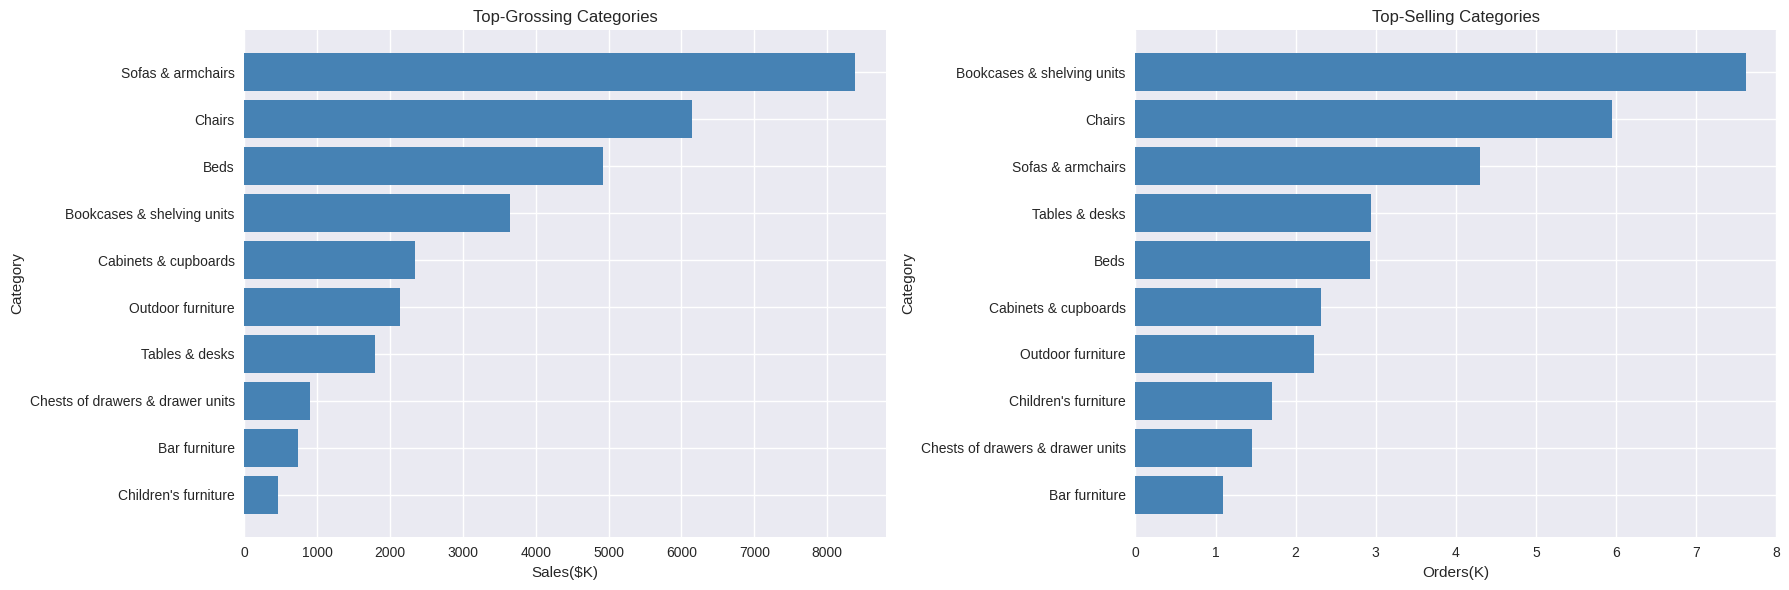

In [ ]:
plt.style.use("seaborn-v0_8")

fig, ax = plt.subplots(1, 2, figsize=(18,6))

ax[0].barh(top_10_categories["category"], top_10_categories["sales_k_usd"], color="steelblue")
ax[0].set_title("Top-Grossing Categories")
ax[0].set_xlabel("Sales($K)")
ax[0].set_ylabel("Category")
ax[0].invert_yaxis()

ax[1].barh(top_10_categories_orders["category"], top_10_categories_orders["orders_k"], color="steelblue")
ax[1].set_title("Top-Selling Categories")
ax[1].set_xlabel("Orders(K)")
ax[1].set_ylabel("Category")
ax[1].invert_yaxis()

plt.tight_layout()
plt.show()

Отже, **найбільш продавана категорія** - **Bookcases & shelving units** (Книжкові шафи та полиці), однак найбільшу **виручку** приносять **Sofas & armchairs** (дивани та крісла), а також Chairs & Beds (стільці та ліжка) за рахунок більшої маржинальності.

In [ ]:
# top-grossing categories in the top-selling country (the USA)

top_10_categories_in_usa = data[data["country"] == "United States"].groupby("category")["sales"].sum().sort_values(ascending=False).reset_index().head(10)
top_10_categories_in_usa["sales"] = (top_10_categories_in_usa["sales"] / 1_000).round(3)
top_10_categories_in_usa.rename(columns={"sales": "sales_k_usd"}, inplace=True)
top_10_categories_in_usa

,category,sales_k_usd
0,Sofas & armchairs,3707.1440000000
1,Chairs,2619.7740000000
2,Beds,2213.0580000000
3,Bookcases & shelving units,1567.6070000000
4,Cabinets & cupboards,994.5460000000
5,Outdoor furniture,929.2450000000
6,Tables & desks,777.8650000000
7,Chests of drawers & drawer units,382.3880000000
8,Bar furniture,330.8050000000
9,Children's furniture,207.5750000000


Як бачимо, **топ найбільш дохідних категорій у країні з найбільшими продажами (США) не відрізняється від загальної картини**.

In [ ]:
# top-grossing products
sales_by_products = data.groupby("item_name")["sales"].sum().div(1_000_000).round(3).sort_values(ascending=False).head(10)
sales_by_products.name = "sales_m_usd"
sales_by_products

,sales_m_usd
item_name,
GRÖNLID,2.2990000000
LIDHULT,2.2580000000
VIMLE,1.7100000000
BESTÅ,1.1010000000
VALLENTUNA,1.0140000000
KIVIK,0.8780000000
BEKANT,0.7980000000
HAVSTA,0.6270000000
SOLLERÖN,0.6040000000


In [ ]:
# best-selling products
orders_by_products = data.groupby("item_name")["sales"].count().sort_values(ascending=False).head(10)
orders_by_products.name = "orders"
orders_by_products

,orders
item_name,
BESTÅ,1257
GRÖNLID,915
TROFAST,813
IVAR,754
VIMLE,724
EKET,695
LIDHULT,593
JONAXEL,562
NORDLI,531


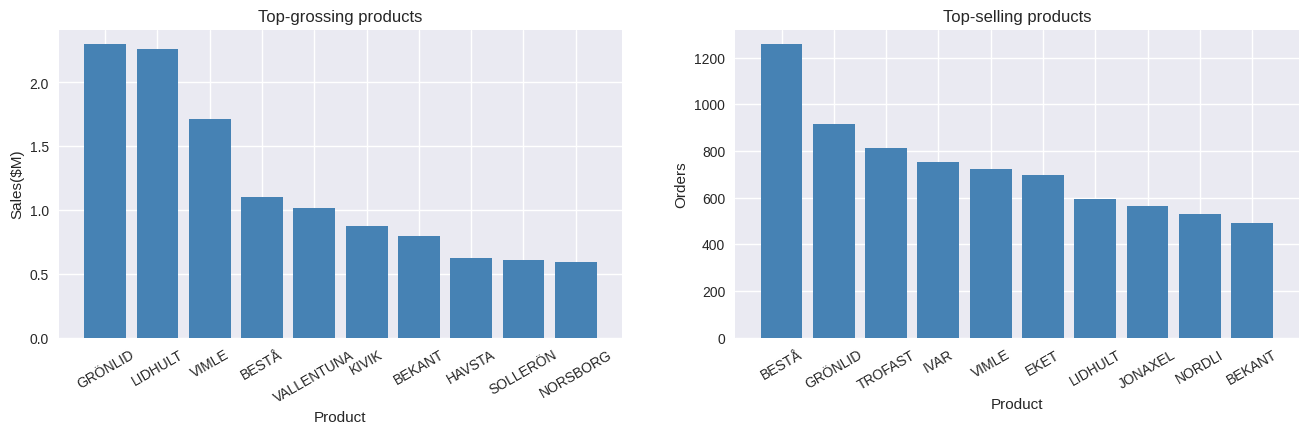

In [ ]:
plt.style.use("seaborn-v0_8")

fig, ax = plt.subplots(1, 2, figsize=(16,4))

ax[0].bar(sales_by_products.index, sales_by_products.values, color="steelblue")
ax[0].set_title("Top-grossing products")
ax[0].set_ylabel("Sales($M)")
ax[0].set_xlabel("Product")
ax[0].tick_params(axis="x", rotation=30)

ax[1].bar(orders_by_products.index, orders_by_products.values, color="steelblue")
ax[1].set_title("Top-selling products")
ax[1].set_ylabel("Orders")
ax[1].set_xlabel("Product")
ax[1].tick_params(axis="x", rotation=30)

plt.tight_layout
plt.show()

Таким чином, **найчастіше замовляють** товари бренду **BESTÅ**, однак **найбільший дохід** приносить **GRÖNLID**, а також **LIDHULT** (BESTÅ - на четвертому місці за сумою продажів).

### Кількість замовлень за мовою користувача (його браузера)

In [ ]:
language_orders = data.groupby("language")["sales"].count().sort_values(ascending=False).reset_index(name="orders")
language_orders

,language,orders
0,en-us,15311
1,en-gb,2344
2,zh,1204
3,en,1098
4,en-ca,891
5,fr,557
6,es-es,550
7,de,304
8,ko,272


Як бачимо, в топі - **американська англійська**. **Англійська** в цілому (у тому числі британська) абсолютно переважає серед інших мов. Також популярною мовою, якою користувачі зробили замовлення, є **китайська**.

###Структура продажів за типами девайсу, моделями, джерелами та каналами продажу


In [ ]:
# components
print(f"All devices names: {data["device"].unique()}")
print(f"All models names: {data["mobile_model_name"].unique()}")
print(f"All traffic sources: {data["traffic_source"].unique()}")
print(f"All traffic channels: {data["channel"].unique()}")

All devices names: ['desktop' 'mobile' 'tablet']
All models names: ['Safari' 'Chrome' '<Other>' 'iPhone' 'Pixel 3' 'ChromeBook' 'iPad'
 'Pixel 4 XL' 'Edge' 'Firefox']
All traffic sources: ['<Other>' 'organic' '(none)' '(data deleted)' 'referral' 'cpc']
All traffic channels: ['Paid Search' 'Organic Search' 'Direct' 'Undefined' 'Social Search']


In [ ]:
#sales by device type

total_sales = data["sales"].sum()
sales_grouped_by_device = data.groupby("device")["sales"].sum()
print(f"Sales % by each device: \n{(sales_grouped_by_device / total_sales * 100).round(2)}")

Sales % by each device: 
device
desktop   59.0000000000
mobile    38.7300000000
tablet     2.2600000000
Name: sales, dtype: float64


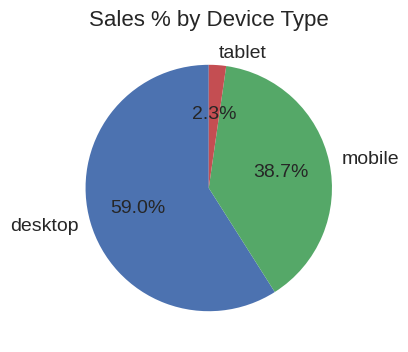

In [ ]:
plt.figure(figsize=(4,4))
plt.pie(sales_grouped_by_device, labels=sales_grouped_by_device.index, autopct="%1.1f%%", startangle=90, textprops={'fontsize': 14})
plt.title("Sales % by Device Type", fontsize=16)
plt.show()

Отже, **найбільше виручки** приносять продажі через **декстопну** версію (59%). Ціна продажів через **планшет** складає **всього 2,3%** від загальної суми.

In [ ]:
# sales by model

sales_percent_by_model = data.groupby(["device", "mobile_model_name"])["sales"].sum().reset_index()
sales_percent_by_model["sales"] = (sales_percent_by_model["sales"] / total_sales * 100).round(2)

pivot_sales_percent_by_model = (sales_percent_by_model.pivot(index="mobile_model_name", columns="device", values="sales").fillna(0))
pivot_sales_percent_by_model = pivot_sales_percent_by_model.loc[pivot_sales_percent_by_model.sum(axis=1).sort_values(ascending=False).index]

print(f"Sales % by each model: \n{pivot_sales_percent_by_model}")

Sales % by each model: 
device                  desktop        mobile       tablet
mobile_model_name                                         
Chrome            27.8400000000  0.0000000000 0.0000000000
<Other>            1.6400000000 17.9400000000 0.8600000000
Safari            20.3000000000  0.0000000000 0.0000000000
iPhone             0.0000000000 20.0800000000 0.0000000000
ChromeBook         5.7300000000  0.0000000000 0.0000000000
Edge               2.1800000000  0.0000000000 0.0000000000
iPad               0.0000000000  0.0000000000 1.4000000000
Firefox            1.3200000000  0.0000000000 0.0000000000
Pixel 4 XL         0.0000000000  0.3700000000 0.0000000000
Pixel 3            0.0000000000  0.3400000000 0.0000000000


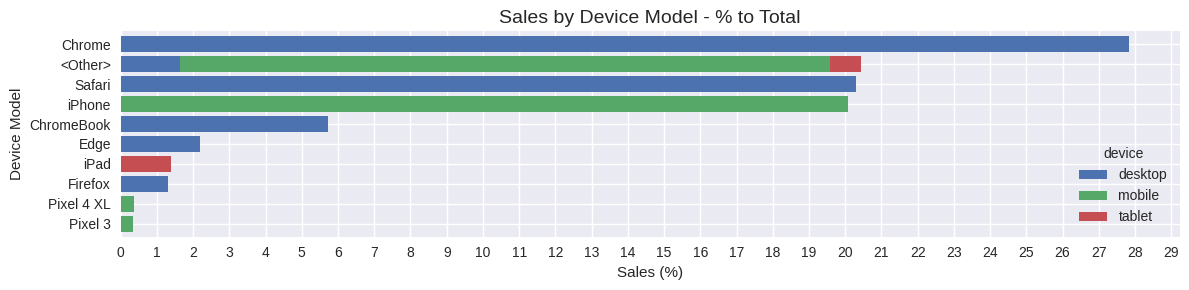

In [ ]:
plt.style.use('seaborn-v0_8')
pivot_sales_percent_by_model.plot(kind="barh", stacked=True, figsize=(12,3), width=0.8)

plt.title("Sales by Device Model - % to Total", fontsize=14)
plt.xlabel("Sales (%)")
plt.ylabel("Device Model")

plt.xticks(np.arange(0, sales_percent_by_model["sales"].max() + 2, 1))
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

Демонстрація належності до типу девайсу допомагає зрозуміти: усі **браузери**, що фіксуються замість моделей, відображають активність користувачів саме на **декстопній версії** (моделі саме цього типу девайсу не ідентифікуються).   

Отже, статистика за окремими моделями телефонів та планшетів *відображає реальну ситуацію*, що важливо для достовірності висновків.

Основні інсайти:
* **"Chome"** - браузер на десктопі, через який купують найбільше - майже **28%** користувачів.
* Значна частка (трохи більше **20%**) припадає на "**Safari**". Ймовірно, більшість покупців цього сегменту користуються продукцією компанії Apple.
* Найбільше покупок через **смартфон** здійснюється на моделі **iPhone** (близько **20%**).
* Варто зазначити, що окрім iPhone, значний відсоток складають також інші моделі, які не вдалося ідентифікувати.




In [ ]:
#sales by traffic source

sales_grouped_by_traffic_source = data.groupby("traffic_source")["sales"].sum()
print(f"Sales % by traffic source: \n{(sales_grouped_by_traffic_source / total_sales * 100).round(2).sort_values(ascending=False)}")

Sales % by traffic source: 
traffic_source
organic          34.2000000000
(none)           23.4400000000
referral         17.6500000000
<Other>          14.0500000000
(data deleted)    6.3900000000
cpc               4.2700000000
Name: sales, dtype: float64


Статистика допомагає побачити загальну картину походження трафіку.  

**Органічне джерело** (перехід за результатами пошуку) переважає (34,2%).
**Реферальне джерело** (перехід за посиланням) також становить значний відсоток - 17.65.
**CPC** (Cost Per Click, тобто перехід через рекламу) становить 4,27%.

Ці дані важливі, щоб оцінити ефективність реклами та спланувати подальші дії бізнесу для залучення більшого трафіку.

Проте цієї інформації не достатньо: оскільки значний відсоток джерел взагалі не ідентифікується, корисно також проаналізувати продажі в розрізі **каналів трафіку**.

In [ ]:
#sales by traffic channel

sales_grouped_by_channel = data.groupby("channel")["sales"].sum().sort_values(ascending=False)
sales_percent_by_channel = (sales_grouped_by_channel / total_sales * 100).round(2).sort_values(ascending=False).reset_index()
print(f"Sales % by channel: \n{sales_percent_by_channel}")

Sales % by channel: 
          channel         sales
0  Organic Search 35.7600000000
1     Paid Search 26.6200000000
2          Direct 23.4400000000
3   Social Search  7.9200000000
4       Undefined  6.2600000000


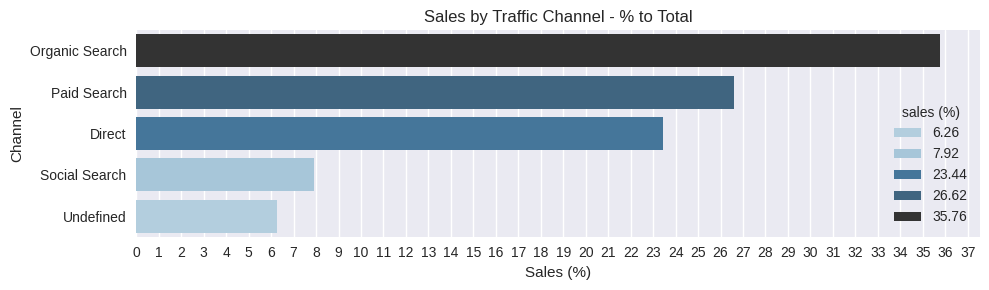

In [ ]:
plt.figure(figsize=(10,3))

sns.barplot(data=sales_percent_by_channel, y="channel", x="sales", hue="sales", palette="Blues_d")
plt.title("Sales by Traffic Channel - % to Total")
plt.xlabel("Sales (%)")
plt.ylabel("Channel")

plt.xticks(np.arange(0, sales_percent_by_channel["sales"].max() + 2, 1))

plt.legend(title="sales (%)")
plt.tight_layout()
plt.show()

Отже, **найчастіше** трафік надходить через органічний пошук (майже 36%). На другому місці - платний пошук (близько 26,5%).

Із визначених каналів трафіку **найменш популярним** є Social Search (близько 8%)

### Аналіз поведінки зареєстрованих та незареєстрованих користувачів

In [ ]:
data[data["account_id"].notna()].head()

,ga_session_id,date,continent,country,device,browser,mobile_model_name,operating_system,language,traffic_source,channel,account_id,is_verified,is_unsubscribed,category,item_name,sales,short_description
28,258365862,2020-11-01,Americas,United States,desktop,Chrome,ChromeBook,<Other>,None,organic,Organic Search,649280,1,1,Bar furniture,FRANKLIN,149.0000000000,"Bar stool with backrest, foldable, 74 cm"
50,1390241795,2020-11-01,Americas,United States,desktop,Chrome,Safari,Web,en-us,(none),Direct,676055,1,1,None,None,NaN,None
58,7169173190,2020-11-01,Americas,United States,desktop,Chrome,Safari,Web,en-us,organic,Organic Search,677981,0,0,None,None,NaN,None
80,2773474671,2020-11-01,Asia,Philippines,desktop,Chrome,ChromeBook,Web,None,organic,Paid Search,672927,1,0,None,None,NaN,None
96,1585785791,2020-11-01,Americas,Canada,desktop,Chrome,ChromeBook,<Other>,en-us,organic,Organic Search,653089,1,0,None,None,NaN,None


In [ ]:
# What percentage of registered users have confirmed their email address?

total_accounts = data["account_id"].nunique()
verified_accounts = data[data["is_verified"] == 1]["account_id"].nunique()
print(f"Verified accounts %: {verified_accounts / total_accounts * 100}")

Verified accounts %: 71.69797817140812


Свою елекронну пошту підтвердили **71,7 відсотка** зареєстрованих користувачів.

In [ ]:
# What percentage of registered users unsubscribed from the mailing list?

unsubscribed_accounts = data[data["is_unsubscribed"] == 1]["account_id"].nunique()
print(f"Unsubscribed accounts %: {unsubscribed_accounts / total_accounts * 100}")

Unsubscribed accounts %: 16.94399713723385


Від розсилки відписалося **16,94%** зареєстрованих користувачів.

In [ ]:
# Is there any difference in behavior between those who have unsubscribed from the mailing list and those who are still subscribed?

sales_depending_on_subscription = data.groupby("is_unsubscribed").agg(total_sales_usd=("sales", "sum"), total_orders=("sales", "count"), total_users=("account_id", "nunique")).reset_index()

sales_depending_on_subscription["orders_per_users_%"] = (sales_depending_on_subscription["total_orders"] / sales_depending_on_subscription["total_users"] * 100).round(2)
sales_depending_on_subscription["mean_sales_per_user_usd"] = (sales_depending_on_subscription["total_sales_usd"] / sales_depending_on_subscription["total_users"]).round(2)
sales_depending_on_subscription["mean_sales_per_order"] = (sales_depending_on_subscription["total_sales_usd"] / sales_depending_on_subscription["total_orders"]).round(2)

sales_depending_on_subscription

,is_unsubscribed,total_sales_usd,total_orders,total_users,orders_per_users_%,mean_sales_per_user_usd,mean_sales_per_order
0,0,2150796.8999999999,2334,23210,10.0600000000,92.6700000000,921.5100000000
1,1,431721.6000000000,447,4735,9.4400000000,91.1800000000,965.8200000000


За розрахунками, підписані на розсилку користувачі в цілому приносять значно більше як доходу, так і замовлень, однак не можна робити висновки без урахування співвідношення кількості користувачів у кожній категорії.

У співвідношенні продажів/замовлень до розміру кожного сегменту різниця не є кардинальною. Та все ще на 100 підписаних користувачів припадає **10 замовлень**. На 100 непідписаних - близько **9**.

Також **середня сума замовлення** на одного підписаного користувача становить 92,67 дол., що на **1,49 дол. більше**, ніж на непідписаного.

Цікаво, що **середній чек** зареєстрованих користувачів навпаки - на **44,31 дол. менший**, ніж незареєстрованих.

Можемо зробити висновки, що поведінка підписаних на пошту та непідписаних користувачів відрізняється, втім дуже не значною мірою.

*Слід зазначити, що різниця в, до прикладу, кількості замовлень не обов'язково є статистично значущою та вказує на важливість email-маркетингу в продажах.* Перевірмо це за допомогою *тесту пропорцій*.

In [ ]:
#z-test
z_stat, p_value = sm.stats.proportions_ztest([2334, 447], [23210, 4735])

print(f"Z-statistic: {z_stat}")
print(f"P-value: {p_value}")

if p_value < 0.05:
    print("There is a significant difference in orders per user.")
else:
    print("There is no significant difference in orders per user.")

Z-statistic: 1.2897602654930744
P-value: 0.19713390786902185
There is no significant difference in orders per user.


Як бачимо, різниця **не є** статистично значущою.

Отже, не можна підтвердити альтернативну гіпотезу про наявність різниці в поведінці зареєстрованих і незареєстрованих користувачів.

In [ ]:
# Which countries have the highest number of registered users?
top_countries_by_accounts = data.groupby("country")["account_id"].nunique().sort_values(ascending=False).reset_index().head(10)
top_countries_by_accounts

,country,account_id
0,United States,12384
1,India,2687
2,Canada,2067
3,United Kingdom,859
4,France,553
5,Spain,536
6,Taiwan,500
7,China,490
8,Germany,490
9,Italy,386


Найбільше зареєстрованих користувачів - в **США, Індії та Канаді**.

### Аналіз динаміки продажів

In [ ]:
sales_by_date = data.groupby("date")["sales"].sum().div(1000)
sales_by_date = sales_by_date.rename("sales_k_usd")
sales_by_date

,sales_k_usd
date,
2020-11-01,244.2925000000
2020-11-02,355.5068000000
2020-11-03,498.9796000000
2020-11-04,339.1871000000
2020-11-05,391.2766000000
...,...
2021-01-27,286.3407000000
2021-01-28,0.0000000000
2021-01-29,0.0000000000


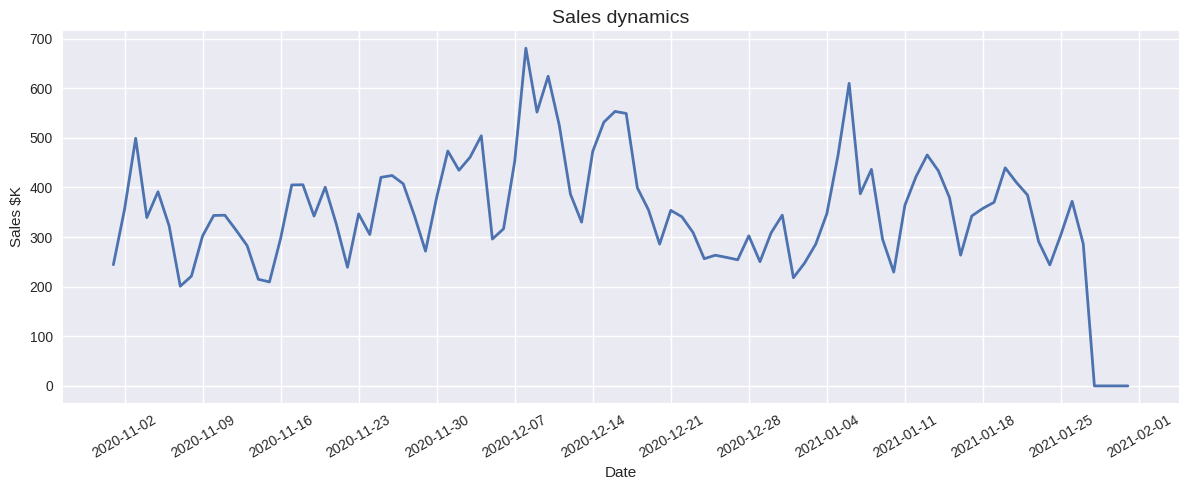

In [ ]:
plt.style.use("seaborn-v0_8")

plt.figure(figsize=(12,5))

plt.plot(sales_by_date, linewidth=2)
plt.title("Sales dynamics", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Sales $K")

plt.gca().xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO, interval=1)) #Each week on the chart begins on Monday.
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

Графік динаміки продажів демонструє виражену **щотижневу сезонність**.

Чітко промальовується повторюваний патерн: **пік** продажів сягається на початку тижня. У другій половині, як правило, спостерігається різкий **спад**. Наприкінці тижня продажі знову починають зростати.

У період з середини *грудня 2020 до початку квітня 2021* продажі, на фоні загальної картини, помітно ***просідали***. Такий спад активності потребує додаткового дослідження контексту і можливих причин.

In [ ]:
data.head()

,ga_session_id,date,continent,country,device,browser,mobile_model_name,operating_system,language,traffic_source,channel,account_id,is_verified,is_unsubscribed,category,item_name,sales,short_description
0,5760483956,2020-11-01,Americas,United States,desktop,Chrome,Safari,Macintosh,zh,<Other>,Paid Search,<NA>,<NA>,<NA>,Bookcases & shelving units,VITTSJÖ,609.0000000000,"Shelving unit with laptop table, 202x36x175 cm"
1,7115337200,2020-11-01,Europe,United Kingdom,desktop,Chrome,Chrome,Web,en-us,organic,Organic Search,<NA>,<NA>,<NA>,Bookcases & shelving units,VITTSJÖ,609.0000000000,"Shelving unit with laptop table, 202x36x175 cm"
2,3978035233,2020-11-01,Europe,Norway,mobile,Chrome,<Other>,Web,zh,(none),Direct,<NA>,<NA>,<NA>,Tables & desks,RÅSKOG,189.0000000000,"Trolley, 35x45x78 cm"
3,9648986282,2020-11-01,Africa,Nigeria,mobile,Chrome,<Other>,Android,es-es,(none),Direct,<NA>,<NA>,<NA>,Bookcases & shelving units,VITTSJÖ,609.0000000000,"Shelving unit with laptop table, 202x36x175 cm"
4,4393441533,2020-11-01,Asia,China,desktop,Chrome,Chrome,Windows,en-us,(none),Direct,<NA>,<NA>,<NA>,Bookcases & shelving units,VITTSJÖ,609.0000000000,"Shelving unit with laptop table, 202x36x175 cm"


In [ ]:
sales_dynamics_by_continent = data[data["continent"].isin(["Americas", "Asia", "Europe"])].groupby(["continent", "date"])["sales"].sum().div(1000).round(3).reset_index()
sales_dynamics_by_continent.rename(columns={"sales": "sales_k"}, inplace=True)
sales_dynamics_by_continent.head()

,continent,date,sales_k
0,Americas,2020-11-01,132.0020000000
1,Americas,2020-11-02,193.8610000000
2,Americas,2020-11-03,294.5300000000
3,Americas,2020-11-04,200.0100000000
4,Americas,2020-11-05,182.9880000000


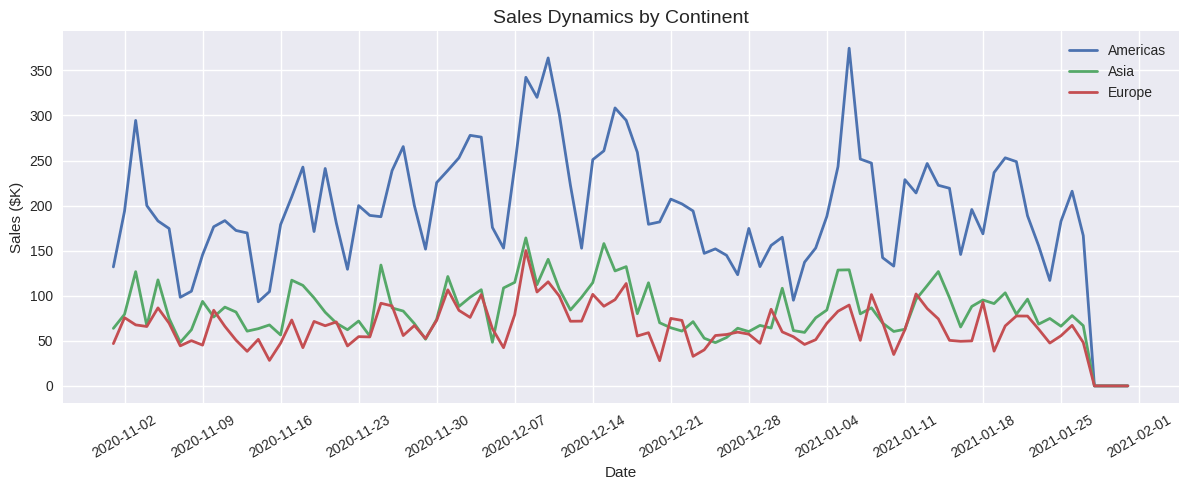

In [ ]:
continents = sales_dynamics_by_continent["continent"].unique()

plt.figure(figsize=(12,5))

for continent in continents:
  continent_data = sales_dynamics_by_continent[sales_dynamics_by_continent["continent"] == continent]
  plt.plot(continent_data["date"], continent_data["sales_k"], linewidth=2, label=continent)
plt.title("Sales Dynamics by Continent", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Sales ($K)")
plt.legend()
plt.grid(True)

plt.gca().xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO, interval=1))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

Усі континенти певною мірою наслідують **загальний патерн** (так само спостерігається тижнева сезонність).  

Слід зазначити, однак, що *продажі в Європі менш стабільні* та передбачувані, ніж в Америці та Азії.

In [ ]:
sales_dynamics_by_device = data.groupby(["device", "date"])["sales"].sum().div(1000).round(3).reset_index()
sales_dynamics_by_device.rename(columns={"sales" : "sales_k"}, inplace=True)
sales_dynamics_by_device.head()

,device,date,sales_k
0,desktop,2020-11-01,144.4450000000
1,desktop,2020-11-02,206.7270000000
2,desktop,2020-11-03,304.4740000000
3,desktop,2020-11-04,212.2280000000
4,desktop,2020-11-05,249.6820000000


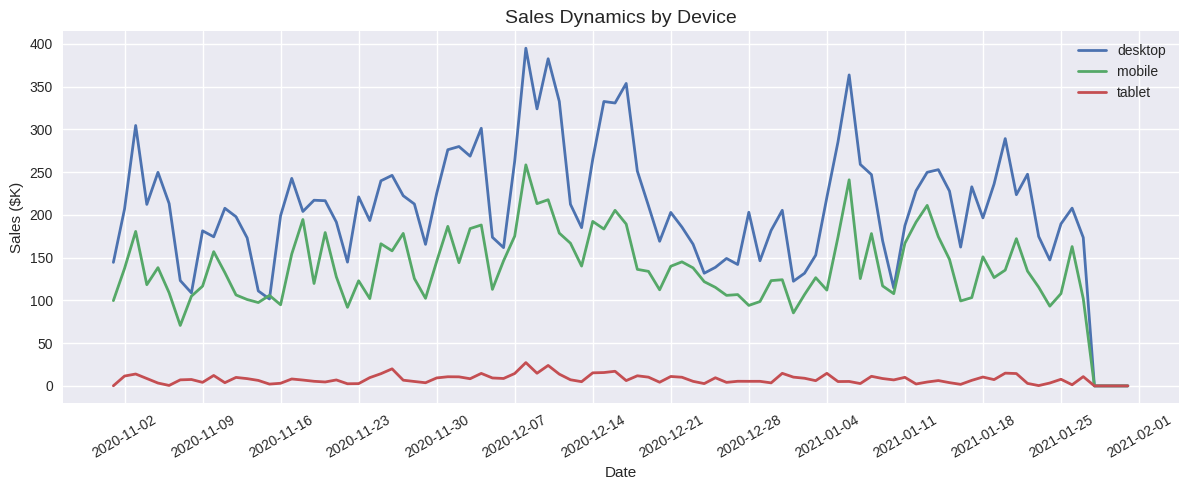

In [ ]:
devices = sales_dynamics_by_device["device"].unique()

plt.figure(figsize=(12,5))

for device_type in devices:
  device_data = sales_dynamics_by_device[sales_dynamics_by_device["device"] == device_type]
  plt.plot(device_data["date"], device_data["sales_k"], linewidth=2, label=device_type)
plt.title("Sales Dynamics by Device", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Sales ($K)")
plt.legend()

plt.gca().xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO, interval=1))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

Продажі через **декстопну та мобільну версію** також наслідують подібний патерн **тижневої сезонності**. **Найбільший дохід** протягом всього періоду приносили користувачі декстопної версії.

Натомість **планшет** вибивається із загальної картини **стабільно низьким рівнем виручки**. Продажі через планшет не вирізняються різкими підйомами чи спадами протягом всього періоду, при цьому час від часу сягають позначок близьких до нуля.

In [ ]:
sales_dynamics_by_channel = data.groupby(["channel", "date"])["sales"].sum().div(1000).reset_index()
sales_dynamics_by_channel.rename(columns={"sales" : "sales_k"}, inplace=True)
sales_dynamics_by_channel.head()

,channel,date,sales_k
0,Direct,2020-11-01,54.6695000000
1,Direct,2020-11-02,81.5615000000
2,Direct,2020-11-03,102.9095000000
3,Direct,2020-11-04,79.6836000000
4,Direct,2020-11-05,83.3676000000


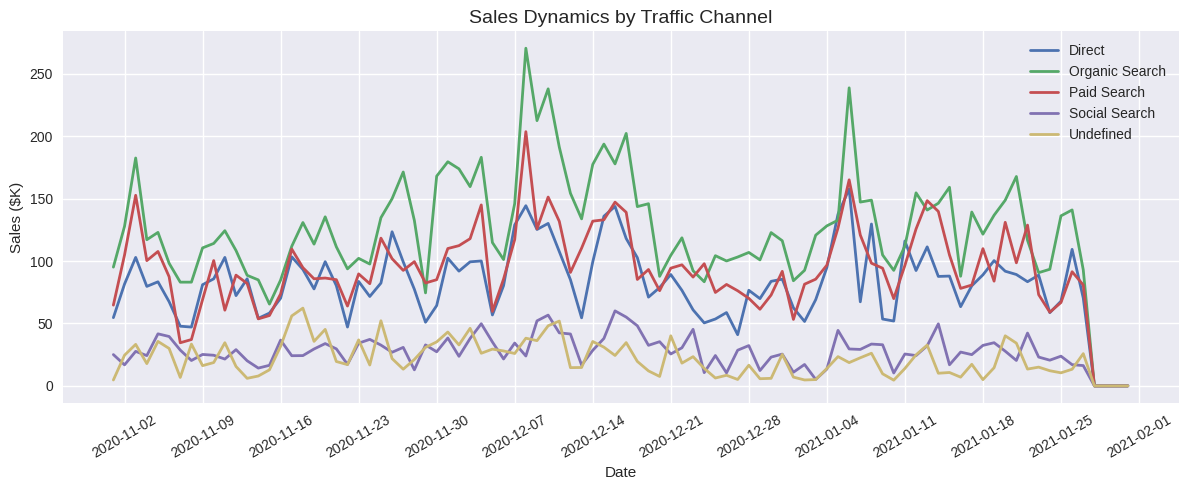

In [ ]:
channels = sales_dynamics_by_channel["channel"].unique()

plt.figure(figsize=(12,5))

for channel in channels:
  channel_data = sales_dynamics_by_channel[sales_dynamics_by_channel["channel"] == channel]
  plt.plot(channel_data["date"], channel_data["sales_k"], linewidth=2, label=channel)
plt.title("Sales Dynamics by Traffic Channel", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Sales ($K)")
plt.legend()

plt.gca().xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO, interval=1))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

Вищенаведений графік демонструє: **найвищі** рівні **продажу** протягом всього періоду досягалися через канал **органічного пошуку** (Organic Search); **найнижчі** (із визначених) - через **соціальний трафік** (Social Search). За останнім, сезонність виражена найменше.

## Блок 3. Зведені таблиці

####Канали трафіку & Тип девайсу: Кількість замовлень

In [ ]:
pivot_channel_device = pd.pivot_table(data, values="ga_session_id", index="device", columns="channel", aggfunc="count", fill_value=0)
pivot_channel_device

channel,Direct,Organic Search,Paid Search,Social Search,Undefined
device,,,,,
desktop,47825,72622,55167,16288,12527
mobile,31745,49014,37034,10988,8486
tablet,1812,2789,2140,638,470


У співвідношенні різні канали трафіку демонструють однакову ефективність за кількістю замовлень на всіх типах девайсу.

####Топ-5 країн & Топ-5 категорій: Сума продажів

In [ ]:
top_5_categories = data.groupby("category")["sales"].sum().sort_values(ascending=False).head(5)

filtered_categories_countries = data[(data["category"].isin(top_5_categories.index)) & (data["country"].isin(top_countries_by_sales.index))]

pivot_category_country = pd.pivot_table(filtered_categories_countries, values="sales", index="country", columns="category", aggfunc="sum")
pivot_category_country

category,Beds,Bookcases & shelving units,Cabinets & cupboards,Chairs,Sofas & armchairs
country,,,,,
Canada,354772.0,278981.9,181802.0,417740.8,692427.5
France,116414.0,73830.0,59101.5,134029.4,187735.0
India,358319.5,364507.4,191888.0,544309.2,788430.0
United Kingdom,133816.0,113987.6,71684.5,188519.4,234812.0
United States,2213058.0,1567606.9,994545.5,2619773.8,3707144.5


#### Топ-10 категорій & Канали трафіку: Кількість замовлень

In [ ]:
filtered_categories = data[data["category"].isin(top_10_categories["category"])]

pivot_category_channel = pd.pivot_table(filtered_categories, values="sales", index="category", columns="channel", aggfunc="count")
pivot_category_channel

channel,Direct,Organic Search,Paid Search,Social Search,Undefined
category,,,,,
Bar furniture,259,397,276,87,73
Beds,666,1063,788,220,189
Bookcases & shelving units,1713,2759,2049,623,486
Cabinets & cupboards,562,803,630,191,132
Chairs,1373,2067,1695,483,334
Chests of drawers & drawer units,347,497,393,115,100
Children's furniture,421,613,424,140,104
Outdoor furniture,540,797,587,170,135
Sofas & armchairs,1007,1503,1160,366,265


Найбільша кількість замовлень спостерігається в категоріях Bookcases & shelving units, Chairs, Sofas & armchairs за такими каналами трафіку як Organic Search та Paid Search, а також Direct.

## Блок 4. Статистичний аналіз взаємозв’язків

### Взаємозв'язок між кількістю сесій та сумою продажів

In [ ]:
pivot_sessions_sales = pd.pivot_table(data=data, values=["ga_session_id", "sales"], index="date", aggfunc={"ga_session_id": "count", "sales": "sum"}).reset_index()
pivot_sessions_sales.columns = ['date', 'sessions', 'total_sales']
pivot_sessions_sales

,date,sessions,total_sales
0,2020-11-01,2576,244292.5000000000
1,2020-11-02,3599,355506.8000000000
2,2020-11-03,5173,498979.6000000000
3,2020-11-04,4184,339187.1000000000
4,2020-11-05,3743,391276.6000000000
...,...,...,...
87,2021-01-27,4435,286340.7000000000
88,2021-01-28,4112,0.0000000000
89,2021-01-29,3700,0.0000000000
90,2021-01-30,2845,0.0000000000


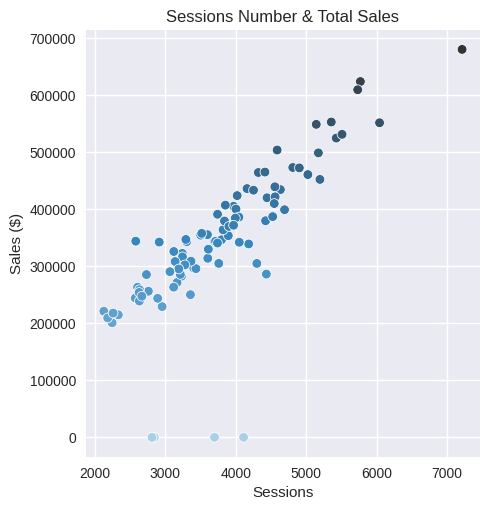

In [ ]:
sns.relplot(data=pivot_sessions_sales, x="sessions", y="total_sales", hue="total_sales", palette="Blues_d", legend=False)
plt.title("Sessions Number & Total Sales")
plt.xlabel("Sessions")
plt.ylabel("Sales ($)")

plt.show()

За реляційним графіком, **між кількістю сесій та сумою виручки** **існує прямопропорційний зв'язок**.

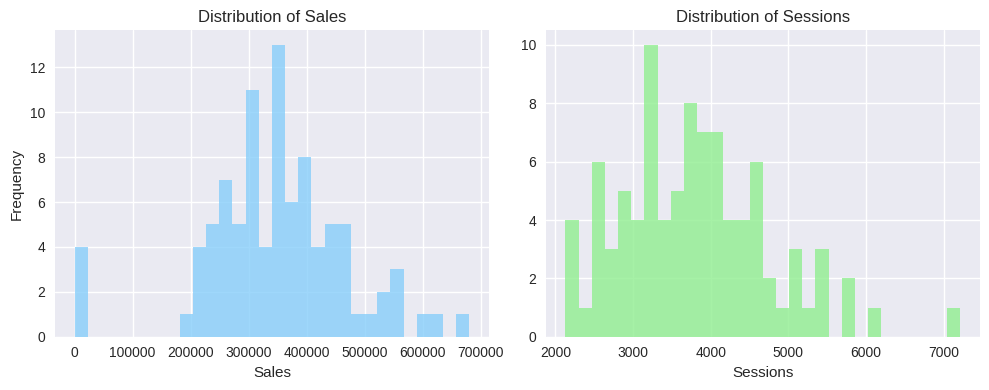

In [ ]:
#normality check

fig, ax = plt.subplots(1, 2, figsize=(10, 4))

ax[0].hist(pivot_sessions_sales["total_sales"], bins=30, color="lightskyblue", alpha=0.8)
ax[0].set_title("Distribution of Sales")
ax[0].set_xlabel("Sales")
ax[0].set_ylabel("Frequency")

ax[1].hist(pivot_sessions_sales["sessions"], bins=30, color="lightgreen", alpha=0.8)
ax[1].set_title("Distribution of Sessions")
ax[1].set_xlabel("Sessions")
ax[0].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

Обидві змінні кількісні та відносно нормально розподілені, тому доцільно застосувати **коефіцієнт кореляції Пірсона**.

In [ ]:
sales_sessions_corr = pivot_sessions_sales["sessions"].corr(pivot_sessions_sales["total_sales"])
print(f"Test statistic and p-value: {pearsonr(pivot_sessions_sales["sessions"], pivot_sessions_sales["total_sales"])}")
print(f"Pearson correlation between sales number and total sales: {sales_sessions_corr}")

Test statistic and p-value: PearsonRResult(statistic=np.float64(0.7910809164540891), pvalue=np.float64(6.483532312080735e-21))
Pearson correlation between sales number and total sales: 0.7910809164540887


 p-value значно менше за 0.05, отже взаємозв'язок можемо вважати статистично значущим.

 Коефіцієнт кореляції є близьким до 1 (становить 0,79) - це означає, що кількість сесій та сума продажів мають **доволі сильний прямий зв'язок**.

### Кореляція продажів на топ 3-х континентах

In [ ]:
# Do sales on different continents correlate with each other?
pivot_top_continents_sales = pd.pivot_table(data=data[data["continent"].isin(["Americas", "Asia", "Europe"])], index="date", columns="continent", values="sales")
pivot_top_continents_sales

continent,Americas,Asia,Europe
date,,,
2020-11-01,851.6290322581,967.0151515152,822.9473684211
2020-11-02,959.7079207921,944.8809523810,1009.4773333333
2020-11-03,950.0961290323,886.2783216783,760.5842696629
2020-11-04,970.9199029126,938.0563380282,803.8414634146
2020-11-05,933.6132653061,1059.5351351351,1169.4594594595
...,...,...,...
2021-01-23,953.0239263804,806.3882352941,1143.3381818182
2021-01-24,713.3500000000,958.9897435897,1080.3363636364
2021-01-25,890.4785365854,735.7244444444,783.3943661972


In [ ]:
pivot_top_continents_sales.corr()

continent,Americas,Asia,Europe
continent,,,
Americas,1.0000000000,0.0342382128,-0.0948679933
Asia,0.0342382128,1.0000000000,0.1301507284
Europe,-0.0948679933,0.1301507284,1.0000000000


In [ ]:
print(f"Test statistic and p-value Americas & Asia: {pearsonr(pivot_top_continents_sales["Americas"], pivot_top_continents_sales["Asia"])}")
print(f"Test statistic and p-value Americas & Europe: {pearsonr(pivot_top_continents_sales["Americas"], pivot_top_continents_sales["Europe"])}")
print(f"Test statistic and p-value Europe & Asia: {pearsonr(pivot_top_continents_sales["Europe"], pivot_top_continents_sales["Asia"])}")

Test statistic and p-value Americas & Asia: PearsonRResult(statistic=np.float64(0.034238212816000764), pvalue=np.float64(0.7514838345248647))
Test statistic and p-value Americas & Europe: PearsonRResult(statistic=np.float64(-0.09486799332612329), pvalue=np.float64(0.3792921842697377))
Test statistic and p-value Europe & Asia: PearsonRResult(statistic=np.float64(0.13015072837644723), pvalue=np.float64(0.22681136138246943))


Детальна інтерпретація результатів:
1) Продажі в **Америці та Азії**:
* Коеф. кореляції - 0.034 => взаємозв'язку майже немає
* ОДНАК p-value = 0.75 => результат статистично *не значущий* (не можемо зробити достовірний висновок щодо тісноти зв'язку)

2) Продажі в **Америці та Європі**:
* p-value = 0.38 => результат статистично *не значущий*

3) Продажі в **Азії та Європі**:
* p-value = 0.27 => результат статистично *не значущий*

Отже, внаслідок статистичного аналізу, **взаємозв'язку** між продажами на різних континентах **виявити не вдалося**.

### Кореляція продажів за каналами трафіку

In [ ]:
# Do sales through different traffic channels correlate with each other?
pivot_channels_date = pd.pivot_table(data=data, index="date", columns="channel", values="sales", fill_value=0)
pivot_channels_date

channel,Direct,Organic Search,Paid Search,Social Search,Undefined
date,,,,,
2020-11-01,759.2986111111,905.8285714286,924.1142857143,1194.1904761905,365.0000000000
2020-11-02,916.4213483146,990.2829457364,1058.3919191919,732.3043478261,877.6785714286
2020-11-03,810.3110236220,981.3005376344,954.0081250000,588.3510638298,811.0829268293
2020-11-04,1021.5846153846,992.0940677966,895.8214285714,758.0437500000,594.9000000000
2020-11-05,1016.6780487805,938.4610687023,1065.8217821782,1158.1444444444,937.6157894737
...,...,...,...,...,...
2021-01-23,1095.2395061728,809.6964285714,891.1597560976,1004.1304347826,1002.3333333333
2021-01-24,751.8487179487,864.9407407407,831.2394366197,858.1708333333,809.7666666667
2021-01-25,869.7948717949,913.9503355705,674.5020202020,881.8148148148,616.5882352941


In [ ]:
pivot_channels_date.corr()

channel,Direct,Organic Search,Paid Search,Social Search,Undefined
channel,,,,,
Direct,1.0000000000,0.3134789855,0.2457008550,-0.1587897488,0.0227221699
Organic Search,0.3134789855,1.0000000000,0.1195811343,-0.1242417053,-0.0550121433
Paid Search,0.2457008550,0.1195811343,1.0000000000,0.0776970375,0.0625398868
Social Search,-0.1587897488,-0.1242417053,0.0776970375,1.0000000000,-0.0530500544
Undefined,0.0227221699,-0.0550121433,0.0625398868,-0.0530500544,1.0000000000


In [ ]:
channels = pivot_channels_date.columns

channels_p_values = pd.DataFrame(index=channels, columns=channels)

for first_channel in channels:
    for second_channel in channels:

        if first_channel == second_channel:
            channels_p_values.loc[first_channel, second_channel] = 0
        else:
            r, p_value = pearsonr(pivot_channels_date[first_channel], pivot_channels_date[second_channel])

            channels_p_values.loc[first_channel, second_channel] = p_value

channels_p_values

channel,Direct,Organic Search,Paid Search,Social Search,Undefined
channel,,,,,
Direct,0,0.00294,0.021032,0.139495,0.833564
Organic Search,0.00294,0,0.26712,0.248787,0.610706
Paid Search,0.021032,0.26712,0,0.471814,0.562687
Social Search,0.139495,0.248787,0.471814,0,0.623509
Undefined,0.833564,0.610706,0.562687,0.623509,0


Статистично значущий результат можемо отримати лише щодо кореляції між продажами з
* прямого та органічного каналів трафіку (p-value = 0.003),
* прямого каналу і платного пошуку (p-value = 0.021).

Коефіцієнт кореляції в парі **Direct & Paid search** - 0.31, що вказує на **слабкий прямий зв'язок**.

Коефіцієнт кореляції 0.25 в парі **Direct & Organic search** свідчить про ще **слабший** прямий зв'язок.

### Кореляція продажів за топ-5 категоріями товарів

In [ ]:
# Do sales in the top 5 product categories correlate with each other?
top_5_categories

,sales
category,
Sofas & armchairs,8388254.5
Chairs,6147748.8
Beds,4919725.0
Bookcases & shelving units,3640818.1
Cabinets & cupboards,2336499.5


In [ ]:
pivot_categories_date = pd.pivot_table(data=data[data["category"].isin(top_5_categories.index)], index="date", columns="category", values="sales", aggfunc="sum", fill_value=0)
pivot_categories_date.head()

category,Beds,Bookcases & shelving units,Cabinets & cupboards,Chairs,Sofas & armchairs
date,,,,,
2020-11-01,14041.0,36701.0,13591.5,46006.0,75216.0
2020-11-02,79683.5,40979.0,21623.0,58834.0,79977.5
2020-11-03,66219.5,64360.1,33555.5,61204.0,175594.0
2020-11-04,48939.0,35719.8,19266.0,44113.0,86861.5
2020-11-05,23449.0,40998.8,29235.0,90388.4,137288.0


In [ ]:
pivot_categories_date.corr()

category,Beds,Bookcases & shelving units,Cabinets & cupboards,Chairs,Sofas & armchairs
category,,,,,
Beds,1.000000,0.592913,0.514609,0.554500,0.535378
Bookcases & shelving units,0.592913,1.000000,0.539428,0.637090,0.666194
Cabinets & cupboards,0.514609,0.539428,1.000000,0.572870,0.657563
Chairs,0.554500,0.637090,0.572870,1.000000,0.578248
Sofas & armchairs,0.535378,0.666194,0.657563,0.578248,1.000000


In [ ]:
categories = pivot_categories_date.columns
categories_p_values = pd.DataFrame(index=categories, columns=categories)

for first_category in categories:
  for second_category in categories:
    if first_category == second_category:
      categories_p_values.loc[first_category, second_category] = 0
    else:
      r, p_value = pearsonr(pivot_categories_date[first_category], pivot_categories_date[second_category])
      categories_p_values.loc[first_category, second_category] = p_value

pd.set_option('display.float_format', lambda x: f'{x:.10f}')
categories_p_values

category,Beds,Bookcases & shelving units,Cabinets & cupboards,Chairs,Sofas & armchairs
category,,,,,
Beds,0,0.0000000012,0.0000002911,0.0000000208,0.0000000769
Bookcases & shelving units,0.0000000012,0,0.0000000587,0.0000000000,0.0000000000
Cabinets & cupboards,0.0000002911,0.0000000587,0,0.0000000055,0.0000000000
Chairs,0.0000000208,0.0000000000,0.0000000055,0,0.0000000036
Sofas & armchairs,0.0000000769,0.0000000000,0.0000000000,0.0000000036,0


Значення p-value в усіх парах найпопулярніших категорій дуже малі, отже  результати є **статистично значущими**.

При цьому всі коефіцієнти кореляції набувають значення від 0.51 до 0.66, що вказує на **помірний прямий взаємозв'язок** продажів між категоріями.

## Блок 5. Статистичний аналіз відмінностей між групами

### Статистичний аналіз відмінностей між середніми чеками зареєстрованих та незареєстрованих користувачів

In [ ]:
data["is_registered"] = data["account_id"].notna().astype(int)
data.head(3)

,ga_session_id,date,continent,country,device,browser,mobile_model_name,operating_system,language,traffic_source,channel,account_id,is_verified,is_unsubscribed,category,item_name,sales,short_description,is_registered
0,5760483956,2020-11-01,Americas,United States,desktop,Chrome,Safari,Macintosh,zh,<Other>,Paid Search,<NA>,<NA>,<NA>,Bookcases & shelving units,VITTSJÖ,609.0000000000,"Shelving unit with laptop table, 202x36x175 cm",0
1,7115337200,2020-11-01,Europe,United Kingdom,desktop,Chrome,Chrome,Web,en-us,organic,Organic Search,<NA>,<NA>,<NA>,Bookcases & shelving units,VITTSJÖ,609.0000000000,"Shelving unit with laptop table, 202x36x175 cm",0
2,3978035233,2020-11-01,Europe,Norway,mobile,Chrome,<Other>,Web,zh,(none),Direct,<NA>,<NA>,<NA>,Tables & desks,RÅSKOG,189.0000000000,"Trolley, 35x45x78 cm",0


In [ ]:
data["is_registered"].value_counts()

,count
is_registered,
0,321600
1,27945


Різниця між кількістю зареєстрованих і незареєстрованих користувачів є кардинальною, тому нам цікаво не порівняти суми виручки (очевидно, вони відповідатимуть розмірам груп), а чи відрізняється статистично значуще **середня сума покупок** між двома вибірками.

In [ ]:
mean_sales_depending_on_registration = data.groupby(["date", "is_registered"])["sales"].mean().reset_index()
mean_sales_depending_on_registration

,date,is_registered,sales
0,2020-11-01,0,860.0212355212
1,2020-11-01,1,979.4090909091
2,2020-11-02,0,927.0149253731
3,2020-11-02,1,1362.3272727273
4,2020-11-03,0,907.0059845560
...,...,...,...
175,2021-01-27,1,769.1368421053
176,2021-01-28,0,NaN
177,2021-01-29,0,NaN
178,2021-01-30,0,NaN


In [ ]:
registered_mean_sales = mean_sales_depending_on_registration[mean_sales_depending_on_registration["is_registered"] == 1]["sales"].dropna()
not_registered_mean_sales = mean_sales_depending_on_registration[mean_sales_depending_on_registration["is_registered"] == 0]["sales"].dropna()
print(registered_mean_sales)
print(not_registered_mean_sales)
print(f"Sample 1 size: {len(registered_mean_sales)}")
print(f"Sample 2 size: {len(not_registered_mean_sales)}")

1      979.4090909091
3     1362.3272727273
5      677.9186046512
7      874.2583333333
9      938.3185185185
            ...      
167    596.9259259259
169    721.1724137931
171    948.9944444444
173    850.4250000000
175    769.1368421053
Name: sales, Length: 88, dtype: float64
0      860.0212355212
2      927.0149253731
4      907.0059845560
6      919.6673410405
8     1013.6897506925
            ...      
166    959.7500000000
168    834.8479400749
170    811.1541916168
172    976.8943342776
174    970.4539285714
Name: sales, Length: 88, dtype: float64
Sample 1 size: 88
Sample 2 size: 88


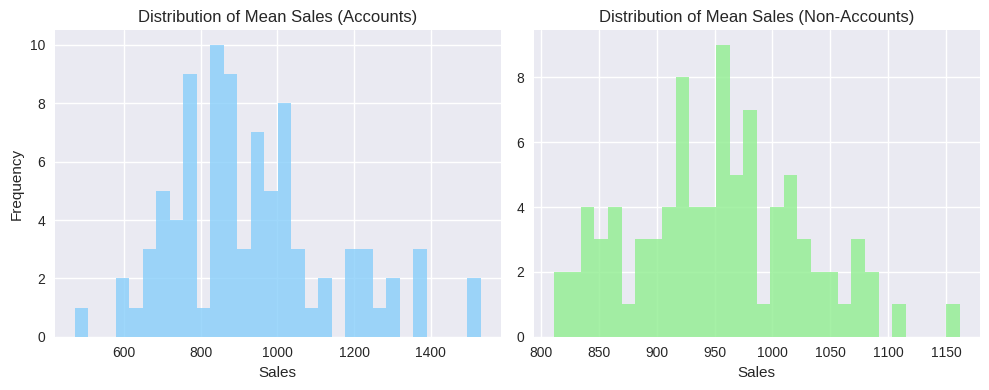

In [ ]:
#data distribution for normality check

fig, ax = plt.subplots(1, 2, figsize=(10, 4))

ax[0].hist(registered_mean_sales, bins=30, color="lightskyblue", alpha=0.8)
ax[0].set_title("Distribution of Mean Sales (Accounts)")
ax[0].set_xlabel("Sales")
ax[0].set_ylabel("Frequency")

ax[1].hist(not_registered_mean_sales, bins=30, color="lightgreen", alpha=0.8)
ax[1].set_title("Distribution of Mean Sales (Non-Accounts)")
ax[1].set_xlabel("Sales")
ax[0].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

Зважаючи на розмір вибірок, для перевірки нормальності використаємо **тест Д'Агостіно-Пірсона**.

Сформулюймо такі гіпотези.  
**Нульова гіпотеза (Н0):** дані у вибірці розподілені нормально (p-value > 0.05).  
**Альтернативна гіпотеза (Н1):** розподіл даних відрізняється від нормального (p-value < 0.05).

In [ ]:
_, p_value_normaltest_registered_mean_sales = normaltest(registered_mean_sales)
_, p_value_normaltest_not_registered_mean_sales = normaltest(not_registered_mean_sales)

print(f"Normaltest for registered users sales p-value: {p_value_normaltest_registered_mean_sales}")
print(f"Normaltest for not registered users sales p-value: {p_value_normaltest_not_registered_mean_sales}")

Normaltest for registered users sales p-value: 0.021780609265212185
Normaltest for not registered users sales p-value: 0.6166314572091707


Для незареєстрованих користувачів приймаємо нульову гіпотезу про нормальність (p-value > 0.05), однак тест показав незначне відхилення від нормального розподілу для групи зареєстрованих користувачів (p-value < 0.05).

Та відповідно до візуальної оцінки розподілу середніх значень у другій групі, такий розподіл можна вважати *близьким до нормального*.

Оскільки середні значення обчислювались для кожної дати на основі різної кількості транзакцій, варіативність показників у групах відрізнялась. Тому для порівняння середніх доцільно використати **тест Велча** (Welch's t-test), який є стійким до нерівності дисперсій.

In [ ]:
t_stat, p_value = ttest_ind(registered_mean_sales, not_registered_mean_sales, equal_var=False)
print(f"T-test t-statistic: {t_stat}, p-value: {p_value}")

T-test t-statistic: -0.9443120745991049, p-value: 0.34710857095515935


p-value 0.35 > 0.05, отже **різниця між середньою сумою покупки на користувача між двома групами не є статистично значущою** (немає достатніх підстав стверджувати, що різниця існує).

### Тест на статистично значущі відмінності між кількістю сесій за каналами трафіку


In [ ]:
sesions_per_day_by_channel = data.groupby(["date", "channel"])["ga_session_id"].count().reset_index(name="sessions")
sesions_per_day_by_channel

,date,channel,sessions
0,2020-11-01,Direct,608
1,2020-11-01,Organic Search,920
2,2020-11-01,Paid Search,706
3,2020-11-01,Social Search,214
4,2020-11-01,Undefined,128
...,...,...,...
455,2021-01-31,Direct,644
456,2021-01-31,Organic Search,1051
457,2021-01-31,Paid Search,729
458,2021-01-31,Social Search,228


In [ ]:
samples = {}
for channel, group in sesions_per_day_by_channel.groupby("channel"):
    samples[channel] = group["sessions"].values

Для визначення нормальності розподілу доцільно застосувати тест Д'Агостіно-Пірсона (normaltest).

In [ ]:
for channel, sample in samples.items():
    stat, p = normaltest(sample)
    print(channel, p)

Direct 0.007853358264896217
Organic Search 0.0031046084804515037
Paid Search 0.0016504167955096551
Social Search 0.21439918696878835
Undefined 0.0402046864129123


Розподіл значень відрізняється від нормального у всіх каналах, окрім Social Search, де p-value > 0.05.

Для порівняння кількох груп у цьому випадку доцільно використати **тест Крускала-Уолліса.**

Та спершу сформулюємо **гіпотези**:  
*Нульова гіпотеза (Н0)* - в середньому кількість сесій між різними каналами трафіку є однаковою.  
*Альтернативна гіпотеза (Н1)* - середня кількість сесій у принаймні одній парі каналів трафіку відрізняється.  

In [ ]:
stat, p_value = kruskal(*samples.values())
print("p-value:", p_value)

p-value: 1.397036102599359e-78


Результати тесту (p-value < 0.05) свідчать про наявність **статистично значущих відмінностей** у кількості сесій між **щонайменше двома каналами трафіку**. Приймаємо альтернативну гіпотезу.

Аби визначити, між якими саме каналами є відмінність, проведемо post-hoc аналіз.

In [ ]:
results = []

channels = list(samples.keys())
n_tests = len(list(combinations(channels, 2)))

for ch1, ch2 in combinations(channels, 2):
    u_stat, p = mannwhitneyu(samples[ch1], samples[ch2], alternative="two-sided")
    results.append({"channel_1": ch1, "channel_2": ch2, "p_value": p})

posthoc_df = pd.DataFrame(results)

# Bonferroni correction
posthoc_df["p_value_adj"] = posthoc_df["p_value"] * n_tests

posthoc_df.sort_values("p_value_adj")

,channel_1,channel_2,p_value,p_value_adj
3,Direct,Undefined,0.0000000000,0.0000000000
8,Paid Search,Undefined,0.0000000000,0.0000000000
6,Organic Search,Undefined,0.0000000000,0.0000000000
7,Paid Search,Social Search,0.0000000000,0.0000000000
5,Organic Search,Social Search,0.0000000000,0.0000000000
2,Direct,Social Search,0.0000000000,0.0000000000
0,Direct,Organic Search,0.0000000000,0.0000000000
4,Organic Search,Paid Search,0.0000000000,0.0000000001
9,Social Search,Undefined,0.0000007912,0.0000079123
1,Direct,Paid Search,0.0001164176,0.0011641756


Попарні порівняння з використанням тесту Манна-Уітні з поправкою Бонферроні показали, що **всі пари каналів мають статистично значущі відмінності у кількості сесій** (p-value_adj < 0.05). Отже, кожен канал має свій **відмінний характерний рівень трафіку**.

Знайдемо середню (за різні дати) кількість сесій для кожного з каналів, щоб зрозуміти, який був найбільш, а який найменш ефективим.

In [ ]:
mean_sesions_by_channel = sesions_per_day_by_channel.groupby("channel")["sessions"].mean().sort_values(ascending=False).reset_index(name="mean_sessions")
mean_sesions_by_channel

,channel,mean_sessions
0,Organic Search,1352.4456521739
1,Paid Search,1025.4456521739
2,Direct,884.5869565217
3,Social Search,303.4130434783
4,Undefined,233.5108695652


**Organic Search** (органічний пошук) в середньому приніс найбільше сесій за весь період, тоді як **Social Search** (серед визначених каналів) виявився найменш ефективним у залученні трафіку.

### Статистичний аналіз  долі сесій з органічним трафіком у Європі та Америці

In [ ]:
organic_sessions_americas = data[(data["continent"] == "Americas") & (data["channel"] == "Organic Search")]["ga_session_id"].count()
print(f"Sessions through Organic Search in Americas: {organic_sessions_americas}")

total_sessions_americas = data[data["continent"] == "Americas"]["ga_session_id"].count()
print(f"Total Sessions Number in Americas: {total_sessions_americas}")

organic_sessions_europe = data[(data["continent"] == "Europe") & (data["channel"] == "Organic Search")]["ga_session_id"].count()
print(f"Sessions through Organic Search in Europe: {organic_sessions_europe}")

total_sessions_europe = data[data["continent"] == "Europe"]["ga_session_id"].count()
print(f"Total Sessions Number in Europe: {total_sessions_europe}")

Sessions through Organic Search in Americas: 68671
Total Sessions Number in Americas: 193179
Sessions through Organic Search in Europe: 23195
Total Sessions Number in Europe: 65135


In [ ]:
#grouping
date_continent_channel_session = data.groupby(["date", "continent", "channel"])["ga_session_id"].count().reset_index(name="sessions")
date_continent_total_session = data.groupby(["date", "continent"])["ga_session_id"].count().reset_index(name="sessions_total")

In [ ]:
#merge
date_continent_channel_session_merged = date_continent_channel_session.merge(date_continent_total_session, on=["date", "continent"], how="left")
date_continent_channel_session_merged["organic_to_total"] = (date_continent_channel_session_merged["sessions"] / date_continent_channel_session_merged["sessions_total"])
date_continent_channel_session_merged

,date,continent,channel,sessions,sessions_total,organic_to_total
0,2020-11-01,(not set),Paid Search,1,2,0.5000000000
1,2020-11-01,(not set),Undefined,1,2,0.5000000000
2,2020-11-01,Africa,Direct,5,16,0.3125000000
3,2020-11-01,Africa,Organic Search,4,16,0.2500000000
4,2020-11-01,Africa,Paid Search,4,16,0.2500000000
...,...,...,...,...,...,...
2568,2021-01-31,Europe,Undefined,31,536,0.0578358209
2569,2021-01-31,Oceania,Direct,5,30,0.1666666667
2570,2021-01-31,Oceania,Organic Search,15,30,0.5000000000
2571,2021-01-31,Oceania,Paid Search,7,30,0.2333333333


In [ ]:
# Americas data
organic_to_total_americas = date_continent_channel_session_merged.loc[(date_continent_channel_session_merged["continent"] == "Americas") & (date_continent_channel_session_merged["channel"] == "Organic Search")]
organic_to_total_americas

,date,continent,channel,sessions,sessions_total,organic_to_total
8,2020-11-01,Americas,Organic Search,534,1474,0.3622795115
35,2020-11-02,Americas,Organic Search,654,1968,0.3323170732
64,2020-11-03,Americas,Organic Search,981,2814,0.3486140725
92,2020-11-04,Americas,Organic Search,799,2255,0.3543237251
122,2020-11-05,Americas,Organic Search,700,2015,0.3473945409
...,...,...,...,...,...,...
2447,2021-01-27,Americas,Organic Search,868,2487,0.3490148774
2475,2021-01-28,Americas,Organic Search,766,2338,0.3276304534
2503,2021-01-29,Americas,Organic Search,725,2027,0.3576714356
2529,2021-01-30,Americas,Organic Search,571,1614,0.3537794300


In [ ]:
# code correctness check
sum_sessions_americas = organic_to_total_americas["sessions_total"].sum()
sum_sessions_americas

np.int64(193179)

In [ ]:
# Europe data
organic_to_total_europe = date_continent_channel_session_merged.loc[(date_continent_channel_session_merged["continent"] == "Europe") & (date_continent_channel_session_merged["channel"] == "Organic Search")]
organic_to_total_europe

,date,continent,channel,sessions,sessions_total,organic_to_total
18,2020-11-01,Europe,Organic Search,170,463,0.3671706263
45,2020-11-02,Europe,Organic Search,228,659,0.3459787557
74,2020-11-03,Europe,Organic Search,340,913,0.3723986857
102,2020-11-04,Europe,Organic Search,267,834,0.3201438849
132,2020-11-05,Europe,Organic Search,259,724,0.3577348066
...,...,...,...,...,...,...
2457,2021-01-27,Europe,Organic Search,280,818,0.3422982885
2485,2021-01-28,Europe,Organic Search,249,720,0.3458333333
2513,2021-01-29,Europe,Organic Search,248,682,0.3636363636
2539,2021-01-30,Europe,Organic Search,184,510,0.3607843137


In [ ]:
sum_sessions_europe = organic_to_total_europe["sessions_total"].sum()
sum_sessions_europe

np.int64(65135)

In [ ]:
share_sample_americas = organic_to_total_americas["organic_to_total"]
share_sample_europe = organic_to_total_europe["organic_to_total"]
print(f"Americas sample size: {share_sample_americas.size}")
print(f"Europe sample size: {share_sample_europe.size}")

Americas sample size: 92
Europe sample size: 92


На основі даних про відношення **щоденної** кількості сесій з органічного трафіку до загальної кількості сесій за регіонами (Америкою та Європою), було сформовано **2 незалежні** вибірки.

Оскільки дані є обмеженими (їхнє значення варіюється від 0 до 1) та не підкоряються нормальному розподілу, для порівняння таких вибірок застосуємо **непараметричний тест Манна-Уітні**.

In [ ]:
# Mann-Whitney test
u_stat, p_value = mannwhitneyu(organic_to_total_europe["organic_to_total"], organic_to_total_americas["organic_to_total"], alternative="two-sided")

print("U-statistic:", u_stat)
print("P-value:", p_value)

if p_value < 0.05:
    print("There is a significant difference in share of sessions with organic traffic in Europe and America.")
else:
    print("There is no significant difference in share of sessions with organic traffic in Europe and America.")

U-statistic: 4288.0
P-value: 0.877891970934652
There is no significant difference in share of sessions with organic traffic in Europe and America.


Окрім цього, для порівняння загальної частки органічного трафіку між Європою та Америкою застосуємо **z-test**. Тест проводиться на основі агрегованих даних за весь період спостереження.

In [ ]:
# z-test
z_stat, p_value = sm.stats.proportions_ztest([organic_sessions_americas, organic_sessions_europe], [total_sessions_americas, total_sessions_europe])

print(f"Z-statistic: {z_stat}")
print(f"P-value: {p_value}")

if p_value < 0.05:
    print("There is a significant difference in share of sessions with organic traffic in Europe and America.")
else:
    print("There is no significant difference in share of sessions with organic traffic in Europe and America.")

Z-statistic: -0.28951412926103953
P-value: 0.7721879690501752
There is no significant difference in share of sessions with organic traffic in Europe and America.


Таким чином, між долями сесій з органічним трафіком у Європі та Америці **немає статистично значущої відмінності**.

### Статистичний аналіз відмінностей у медіанних чеках за типом девайсу користувача

In [ ]:
daily_median_sales_by_device = data.groupby(["date", "device"])["sales"].median().reset_index(name="median_sales")
daily_median_sales_by_device.head(10)

,date,device,median_sales
0,2020-11-01,desktop,500.0000000000
1,2020-11-01,mobile,397.0000000000
2,2020-11-01,tablet,149.0000000000
3,2020-11-02,desktop,445.0000000000
4,2020-11-02,mobile,447.5000000000
5,2020-11-02,tablet,395.0000000000
6,2020-11-03,desktop,425.0000000000
7,2020-11-03,mobile,385.0000000000
8,2020-11-03,tablet,845.0000000000
9,2020-11-04,desktop,407.0000000000


In [ ]:
desktop_sample = daily_median_sales_by_device[daily_median_sales_by_device["device"] == "desktop"]["median_sales"].dropna()
print(desktop_sample)

mobile_sample = daily_median_sales_by_device[daily_median_sales_by_device["device"] == "mobile"]["median_sales"].dropna()
print(mobile_sample)

tablet_sample = daily_median_sales_by_device[daily_median_sales_by_device["device"] == "tablet"]["median_sales"].dropna()
print(tablet_sample)

0     500.0000000000
3     445.0000000000
6     425.0000000000
9     407.0000000000
12    426.5000000000
           ...      
249   485.5000000000
252   392.0000000000
255   380.0000000000
258   450.0000000000
261   400.0000000000
Name: median_sales, Length: 88, dtype: float64
1     397.0000000000
4     447.5000000000
7     385.0000000000
10    495.0000000000
13    445.0000000000
           ...      
250   395.0000000000
253   417.5000000000
256   370.0000000000
259   497.5000000000
262   549.5000000000
Name: median_sales, Length: 88, dtype: float64
2     149.0000000000
5     395.0000000000
8     845.0000000000
11    795.0000000000
14    295.0000000000
           ...      
251   187.0000000000
254   550.5000000000
257   295.0000000000
260   662.5000000000
263   485.0000000000
Name: median_sales, Length: 88, dtype: float64


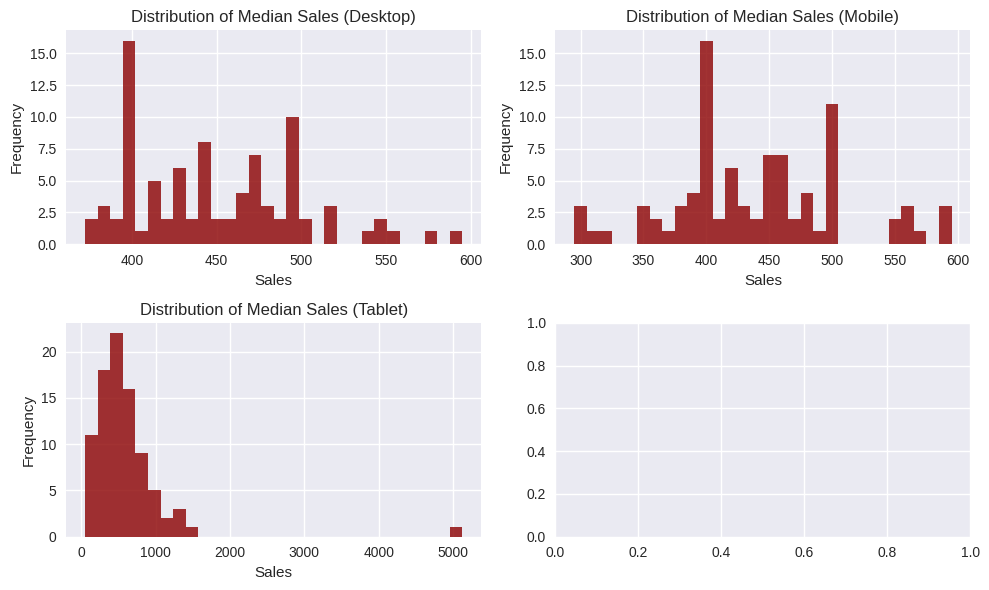

In [ ]:
fig, ax = plt.subplots(2, 2, figsize=(10, 6))

ax[0, 0].hist(desktop_sample, bins=30, color="darkred", alpha=0.8)
ax[0, 0].set_title("Distribution of Median Sales (Desktop)")
ax[0, 0].set_xlabel("Sales")
ax[0, 0].set_ylabel("Frequency")

ax[0, 1].hist(mobile_sample, bins=30, color="darkred", alpha=0.8)
ax[0, 1].set_title("Distribution of Median Sales (Mobile)")
ax[0, 1].set_xlabel("Sales")
ax[0, 1].set_ylabel("Frequency")

ax[1, 0].hist(tablet_sample, bins=30, color="darkred", alpha=0.8)
ax[1, 0].set_title("Distribution of Median Sales (Tablet)")
ax[1, 0].set_xlabel("Sales")
ax[1, 0].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

In [ ]:
stat, p_value = kruskal(desktop_sample, mobile_sample, tablet_sample)
print(p_value)

0.028575422013771817


Результати тесту Крускала-Уолліса свідчать про наявність **статистично значущих відмінностей** (p-value < 0.05) між медіанними сумами продажів з різних девайсів.

## Ключові висновки

1. Бізнес **структурно залежить** від континенту Америки, який формує переважну більшість виручки та замовлень. Ключовим ринком є **США**.

2. Виручку формують "high-ticket" категорії (**дивани та крісла**, стільці, ліжка), тоді як найбільшу кількість замовлень генерують **книжкові шафи та полиці**.

3. **Десктоп** - головний канал **монетизації** (приность близько 59% виручки), а планшет характеризується мінімальною роллю в продажах (близько 2%), при цьому відмінності між всіма типами пристроїв статистично значущі.

4. **Основний трафік і дохід** формуються через **органічний пошук**, що вказує на стратегічно важливу роль SEO у моделі зростання.

5. Paid Search забезпечує значну частку сесій, що вказує на **залежність від платного залучення**. Social - найменш ефективний канал серед визначених.

6. Між кількістю сесій та виручкою існує сильний позитивний зв’язок (r = 0.79). Можемо припустити, що **масштабування трафіку є драйвером доходу**.

7. **Email-маркетинг не демонструє статистично значущого впливу** на середній чек або частоту замовлень.

8. **Продажі** мають стабільну **тижневу сезонність** у всіх регіонах, за всіма каналами трафіку та типами девайсу (окрім планшета).

9. Регіони функціонують незалежно (суттєвого взаємозв’язку між континентами не виявлено).

10. Період системного спаду продажів потребує додаткового аналізу зовнішніх і внутрішніх факторів.

## Посилання на дашборди

https://public.tableau.com/views/Project1_17725671683830/SalesAnalysis?:language=en-GB&publish=yes&:sid=&:redirect=auth&:display_count=n&:origin=viz_share_link

https://public.tableau.com/views/Project1_17725671683830/OrdersDynamics?:language=en-GB&publish=yes&:sid=&:redirect=auth&:display_count=n&:origin=viz_share_link